In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import astropy.units as u
from tqdm import tqdm
import glob, os

import sys
sys.path.append("../scripts")
from forward_model import make_wcs

import matplotlib.pylab as pylab
plt.style.use("science")
params = {
         'axes.labelsize': 20,
         'axes.titlesize': 25,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }
pylab.rcParams.update(params)


# Run this after running aligning_smacs_targets_drizzlepac since we update the WCS there

In [2]:
from scipy.interpolate import interpn
from matplotlib.colors import Normalize
import matplotlib.cm as cm


def density_scatter(points, fig=None, ax=None, sort=True, bins=20, cmap="magma", norm=None, ticks=None, colorbar=False, **kwargs):
    """
    Scatter plot colored by 2d histogram
    """
    x = points[:, 0]
    y = points[:, 1]
    if ax is None:
        fig, ax = plt.subplots()
    data, x_edges, y_edges = np.histogram2d(x, y, bins=bins, density=True)
    x_bins = 0.5 * (x_edges[1:] + x_edges[:-1])
    y_bins = 0.5 * (y_edges[1:] + y_edges[:-1])
    z = interpn((x_bins, y_bins), data, np.vstack([x, y]).T, method="splinef2d", bounds_error=False)
    z[np.where(np.isnan(z))] = 0.0
    # Sort the points by density, so that the densest points are plotted last
    if sort:
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    if norm is None:
        norm = Normalize(vmin=z.min(), vmax=z.max())
    ax.scatter(x, y, c=z, cmap=cmap, norm=norm, **kwargs)
    if fig is not None:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        box = ax.get_position()
        cax = plt.axes([box.x0*1.01 + box.width * 1.05, box.y0, 0.02, box.height])
        fig.colorbar(sm, cax=cax, ticks=ticks)
        cax.set_ylabel('Density')
    return ax


In [3]:
def interpolate(image, x, y, zero_fill=True):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    H, W = image.shape
    x = x.flatten()
    y = y.flatten()
    idxs_out_of_bounds = (y < 0) | (y > W-1) | (x < 0) | (x > W-1)
    x0 = np.floor(x).astype(np.int32)
    x1 = x0 + 1
    y0 = np.floor(y).astype(np.int32)
    y1 = y0 + 1

    x0 = np.clip(x0, 0, W - 1)
    x1 = np.clip(x1, 0, W - 1)
    y0 = np.clip(y0, 0, H - 1)
    y1 = np.clip(y1, 0, H - 1)
    x = np.clip(x, 0, W - 1)
    y = np.clip(y, 0, H - 1)

    Ia = image[x0, y0]
    Ib = image[x0, y1]
    Ic = image[x1, y0]
    Id = image[x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    result = (wa * Ia + wb * Ib + wc * Ic + wd * Id)
    result[idxs_out_of_bounds] = 0

    return result


# Load data

In [7]:
data_dir = "../data/COSMOS45-05/"
# drz_path = glob.glob(data_dir + "*drz.fits")[0]
# flc_paths = glob.glob(data_dir + "*flc.fits") # in principle, we will only use flc, since they hace the additional CTE correction
paths = glob.glob(data_dir + "*flt.fits")

In [26]:
TARGET = 2


coord0 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(u.hourangle, u.deg))
coord1 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(u.hourangle, u.deg))

coords = [coord0, coord1, coord2]
coord = coords[TARGET]


# We need to make larger cutouts to have more context to make alignment faithful 
size = 64
cutouts = {i: [] for i in range(3)}
wcs_lists = {i: [] for i in range(3)}
for i, path in enumerate(paths):
    data = fits.open(path)
    for target in range(3):
        if target == 0: # on CCD chip 1
            cutout = Cutout2D(data["SCI", 2].data, coords[target], size, wcs=WCS(data["SCI", 2].header, data))
        else: # on CCD chip 2
            cutout = Cutout2D(data["SCI", 1].data, coords[target], size, wcs=WCS(data["SCI", 1].header, data))       
        wcs = cutout.wcs
        cutouts[target].append(cutout.data)
        wcs_lists[target].append(wcs)

observations = np.stack(cutouts[TARGET], axis=0)
wcs_list = wcs_lists[TARGET]

In [27]:
# Should be solution found previously
for p in paths:
    current_wcs = fits.getval(p, 'WCSNAME', ext=('SCI', 1))
    print(current_wcs)

IDC_4bb1536oj-FIT_REL_GAIAeDR3
IDC_4bb1536oj-FIT_REL_GAIAeDR3
IDC_4bb1536oj-FIT_REL_GAIAeDR3
IDC_4bb1536oj-FIT_REL_GAIAeDR3


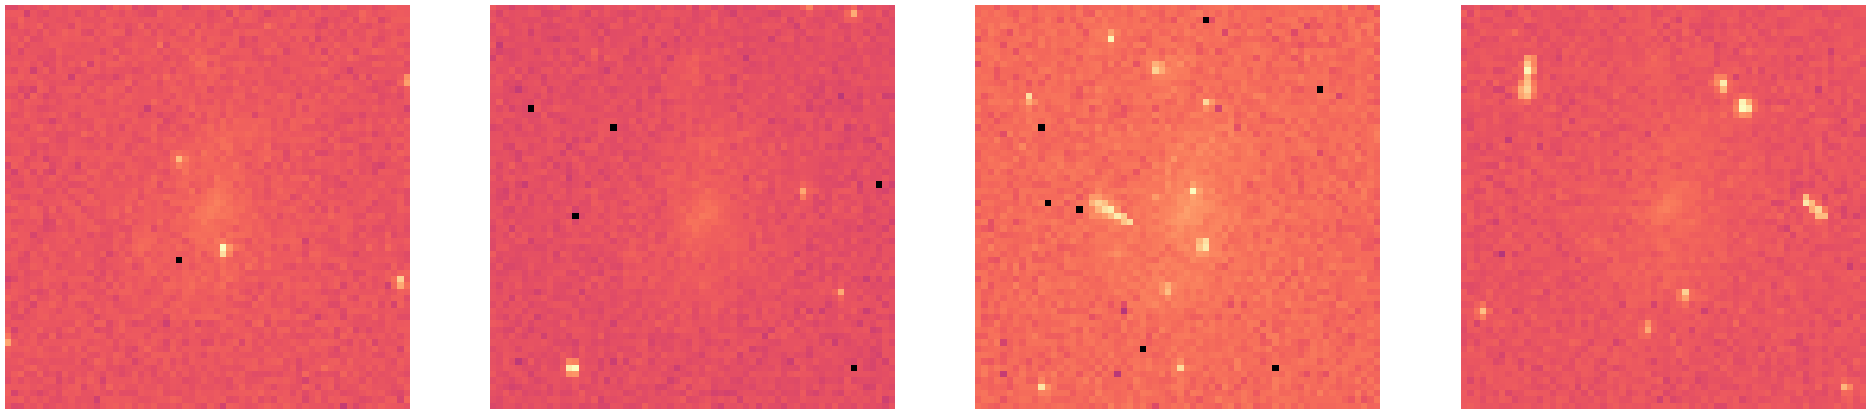

In [28]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[i], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[i].axis("off")

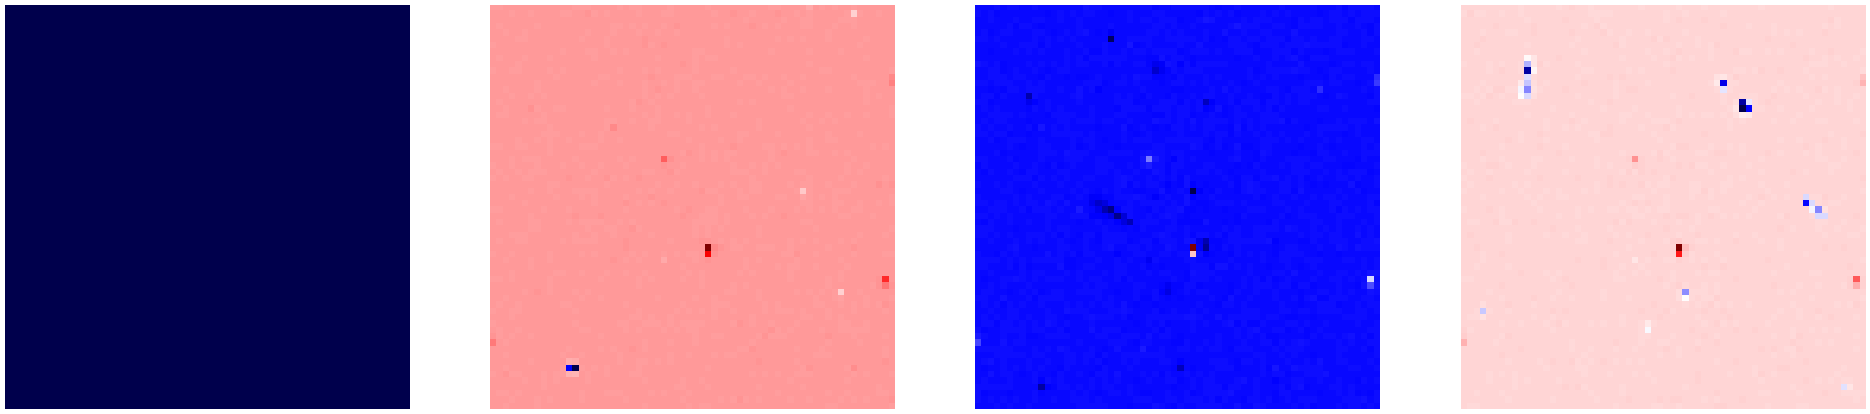

In [29]:
fig, axs = plt.subplots(1, len(wcs_list), figsize=(6*len(wcs_list), 6))
for i in range(len(wcs_list)):
    axs[i].imshow(observations[0] - observations[i], cmap="seismic")
    axs[i].axis("off")

In [41]:
pixels = observations.shape[2]

def forward(shift_x, shift_y, theta, i, i_ref):
    # assert i != i_ref
    wcs_ref = wcs_list[i_ref]
    wcs_target = wcs_list[i]
    hdr = wcs_target.to_header(True) # True makes it so that we have the SIP coefficients

    pc = wcs_target.pixel_scale_matrix
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta), np.cos(theta)]])
    
    new_pc = rotation @ pc
    hdr["PC1_1"] = new_pc[0, 0]
    hdr["PC1_2"] = new_pc[0, 1]
    hdr["PC2_1"] = new_pc[1, 0]
    hdr["PC2_2"] = new_pc[1, 1]
    hdr["CRVAL1"] = hdr["CRVAL1"] + shift_y / 3600 # arcsec to deg
    hdr["CRVAL2"] = hdr["CRVAL2"] + shift_x / 3600
    # make a new wcs based on shift and rotation of the model
    new_wcs = WCS(hdr)
    y_target = observations[i]

    # Construct coordinate grid of reference observation
    u = np.arange(wcs_ref.pixel_shape[0])# + 0.5 Should not add this 0.5 when making coordinates!!
    v = np.arange(wcs_ref.pixel_shape[1])# + 0.5
    u, v = np.meshgrid(u, v, indexing="ij")
    # Then map to reference WCS
    world = wcs_ref.pixel_to_world(u, v)
    # Then map to target pixel grid
    pixel_x, pixel_y = np.stack(new_wcs.world_to_pixel(world), axis=0)
    
    # Finally interpolate data on this coordinate system
    y = interpolate(y_target, pixel_x, pixel_y)
    return y.reshape(*wcs_ref.pixel_shape)



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 58.71it/s]


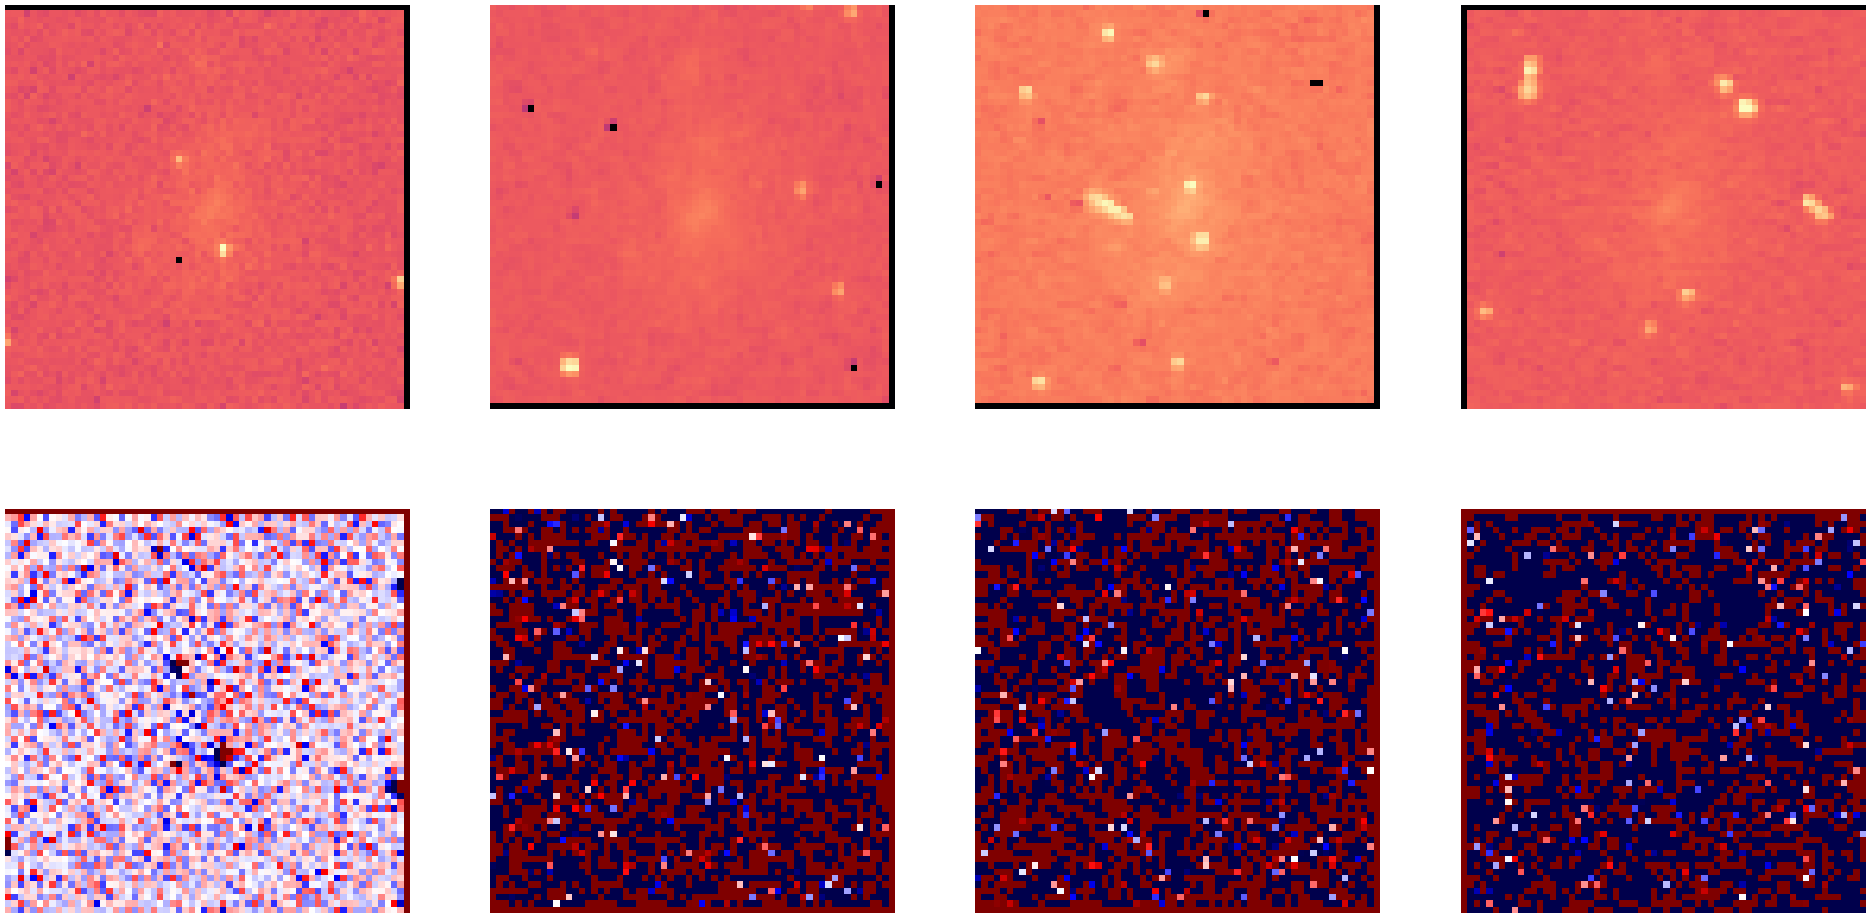

In [42]:
fig, axs = plt.subplots(2, len(wcs_list), figsize=(6 * len(wcs_list), 12), sharey=True)

i_ref = 0
index = 0
for i in tqdm(range(len(wcs_list))):
    y = forward(0, 0, 0, i, i_ref)
    axs[0, index].imshow(y, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
    axs[1, index].imshow(observations[i_ref] - y, cmap="seismic", vmin=-1, vmax=1)
    index += 1
        
for i in range(2):
    for j in range(len(wcs_list)):
        axs[i, j].axis("off")